https://unit8co.github.io/darts/examples/13-TFT-examples.html <br>
https://docs.pytorch.org/docs/stable/generated/torch.load.html <br>
https://pytorch-forecasting.readthedocs.io/en/v1.4.0/tutorials/stallion.html

# Packages, requirements, and source documents

!pip uninstall -y coverage pytest-cov 

!pip install "coverage>=7.4" "pytest-cov>=4.1"

In [1]:
#Packages and settings
%load_ext autoreload
%autoreload 2
%matplotlib inline

# use darts plotting style
code
python

# Interpretability: inline helper functions + analysis for one state\n
import numpy as np\n
import pandas as pd\n
import matplotlib.pyplot as plt\n
import seaborn as sns\n
from darts import TimeSeries\n
from statsmodels.graphics.tsaplots import plot_acf\n
from statsmodels.graphics.gofplots import qqplot\n
from statsmodels.stats.diagnostic import acorr_ljungbox\n
from statsmodels.stats.stattools import durbin_watson\n
from scipy.stats import shapiro\n
\n
# --- Metrics ---\n
def rmse(y_true, y_pred):\n
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)\n
    return np.sqrt(np.mean((y_true - y_pred) ** 2))\n
\n
def mae(y_true, y_pred):\n
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)\n
    return np.mean(np.abs(y_true - y_pred))\n
\n
def mape(y_true, y_pred):\n
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)\n
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100\n
\n
def mase(y_true, y_pred, insample, m=1):\n
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)\n
    insample = np.asarray(insample)\n
    denom = np.mean(np.abs(insample[m:] - insample[:-m]))\n
    if denom == 0:\n
        return np.nan\n
    return np.mean(np.abs(y_true - y_pred)) / denom\n
\n
# --- Attention summarizer ---\n
def summarize_attention(attention_array, feature_names=None, ax=None, cmap='viridis', savepath=None):\n
    att = np.asarray(attention_array)\n
    if att.ndim <= 2:\n
        avg_attn = att\n
    else:\n
        avg_attn = att.mean(axis=tuple(range(att.ndim - 2)))\n
    fig = None\n
    if ax is None:\n
        fig, ax = plt.subplots(figsize=(8, 4))\n
    sns.heatmap(avg_attn, ax=ax, cmap=cmap, cbar=True)\n
    ax.set_title('Average attention')\n
    if feature_names is not None:\n
        try:\n
            ax.set_xticklabels(feature_names, rotation=45, ha='right')\n
        except Exception:\n
            pass\n
    if savepath is not None:\n
        fig.tight_layout()\n
        fig.savefig(savepath, dpi=150)\n
    return avg_attn\n
\n
# --- Permutation importance ---\n
def permutation_importance(predict_fn, X_val, y_val, metric_func, n_repeats=5, random_state=None):\n
    rng = np.random.RandomState(random_state)\n
    Xdf = pd.DataFrame(X_val) if not isinstance(X_val, pd.DataFrame) else X_val.copy()\n
    baseline = metric_func(y_val, predict_fn(Xdf))\n
    importances = {}\n
    for col in Xdf.columns:\n
        scores = []\n
        for _ in range(n_repeats):\n
            Xp = Xdf.copy()\n
            Xp[col] = rng.permutation(Xp[col].values)\n
            yp = predict_fn(Xp)\n
            scores.append(metric_func(y_val, yp))\n
        importances[col] = np.mean(scores) - baseline\n
    return pd.Series(importances).sort_values(ascending=False)\n
\n
# --- Residual analysis ---\n
def residual_analysis(y_true, y_pred, insample=None, m=12, plot_prefix=None, show_plots=False):\n
    y_true = np.asarray(y_true)\n
    y_pred = np.asarray(y_pred)\n
    resid = y_true - y_pred\n
    stats = {\n
        'n': resid.shape[0],\n
        'RMSE': rmse(y_true, y_pred),\n
        'MAE': mae(y_true, y_pred),\n
        'MAPE': mape(y_true, y_pred),\n
        'MASE': mase(y_true, y_pred, insample=insample if insample is not None else y_true, m=m),\n
        'MeanResidual': np.mean(resid),\n
        'StdResidual': np.std(resid),\n
    }\n
    try:\n
        lb = acorr_ljungbox(resid, lags=[10], return_df=True)\n
        stats['LjungBox_pvalue_lag10'] = float(lb['lb_pvalue'].iloc[0])\n
    except Exception:\n
        stats['LjungBox_pvalue_lag10'] = None\n
    try:\n
        sh_stat, sh_p = shapiro(resid)\n
        stats['Shapiro_pvalue'] = float(sh_p)\n
    except Exception:\n
        stats['Shapiro_pvalue'] = None\n
    try:\n
        stats['DurbinWatson'] = float(durbin_watson(resid))\n
    except Exception:\n
        stats['DurbinWatson'] = None\n
    figs = {}\n
    fig_ts, ax_ts = plt.subplots(figsize=(8, 3))\n
    ax_ts.plot(resid, marker='.', linestyle='-', alpha=0.6)\n
    ax_ts.axhline(0, color='k', linewidth=0.8)\n
    ax_ts.set_title('Residuals over time')\n
    figs['residuals_ts'] = fig_ts\n
    if plot_prefix:\n
        fig_ts.tight_layout()\n
        fig_ts.savefig(f
, dpi=150)\n
    fig_acf, ax_acf = plt.subplots(figsize=(6, 3))\n
    plot_acf(resid, ax=ax_acf, lags=40)\n
    ax_acf.set_title('ACF of residuals')\n
    figs['residuals_acf'] = fig_acf\n
    if plot_prefix:\n
        fig_acf.tight_layout()\n
        fig_acf.savefig(f
, dpi=150)\n
    fig_hist, ax_hist = plt.subplots(figsize=(6, 3))\n
    sns.histplot(resid, kde=True, ax=ax_hist)\n
    ax_hist.set_title('Residual distribution')\n
    figs['residuals_hist'] = fig_hist\n
    if plot_prefix:\n
        fig_hist.tight_layout()\n
        fig_hist.savefig(f
, dpi=150)\n
    fig_qq = qqplot(resid, line='s')\n
    fig_qq.suptitle('QQ-plot of residuals')\n
    figs['residuals_qq'] = fig_qq\n
    if plot_prefix:\n
        fig_qq.tight_layout()\n
        fig_qq.savefig(f
, dpi=150)\n
    if not show_plots:\n
        plt.close('all')\n
    return {'stats': stats, 'figs': figs, 'residuals': resid}\n
\n
# --- Run analysis for one state ---\n
state_name = next(iter(state_results.keys()))\n
print('Analyzing state:', state_name)\n
data = state_results[state_name]\n
scaler = data['scaler_target']\n
pred_ts = state_preds[state_name]  # darts TimeSeries (probabilistic)\n
pred_inv = scaler.inverse_transform(pred_ts)\n
val_inv = scaler.inverse_transform(data['val_transformed'])\n
train_inv = scaler.inverse_transform(data['train_transformed'])\n
samples = pred_inv.all_values()[:, 0, :]\n
median_pred = np.median(samples, axis=1)\n
y_true = val_inv.values().flatten()\n
y_pred = median_pred\n
res = residual_analysis(y_true, y_pred, insample=train_inv.values().flatten(), plot_prefix=f'{state_name}_res', show_plots=False)\n
print('Residual stats:')\n
for k, v in res['stats'].items():\n
    print(f'  {k}: {v}')\n
\n
# Try to extract attention (best-effort)\n
try:\n
    att = None\n
    if hasattr(eval_model, 'model'):\n
        model_obj = eval_model.model\n
        if hasattr(model_obj, 'get_attention'):\n
            att = model_obj.get_attention()\n
        elif hasattr(model_obj, 'encoder_attentions'):\n
            att = model_obj.encoder_attentions\n
    if att is None:\n
        print('No accessible attention weights found on model; skipping attention visualization.')\n
    else:\n
        avg = summarize_attention(att, savepath=f'{state_name}_attention.png')\n
        print('Saved attention heatmap:', f'{state_name}_attention.png')\n
except Exception as e:\n
    print('Error extracting attention:', e)\n
\n
# Permutation importance for future covariates (may be slow)\n
try:\n
    pred_times = pred_ts.time_index\n
    fut_df = data['fut_cov_unscaled'].to_dataframe()\n
    try:\n
        X_base = fut_df.loc[pred_times].copy()\n
    except Exception:\n
        X_base = fut_df.iloc[:len(pred_times)].copy()\n
    def predict_fn_perm(Xdf):\n
        ts = TimeSeries.from_dataframe(Xdf, freq='MS')\n
        fut_scaled = data['scaler_future'].transform(ts)\n
        pred = eval_model.predict(\n
            n=len(pred_times),\n
            series=data['train_transformed'],\n
            future_covariates=fut_scaled,\n
            past_covariates=data['past_cov_transformed'],\n
            num_samples=1,\n
            verbose=False,\n
        )\n
        return pred.all_values()[:, 0, 0]\n
    imp = permutation_importance(predict_fn_perm, X_base, y_true, metric_func=rmse, n_repeats=3, random_state=0)\n
    print('\nPermutation importance (mean increase in RMSE):')\n
    print(imp)\n
except Exception as e:\n
    print('Permutation importance failed:', e)\n
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
, 'highest_category' #Florida only, dropping for now
, 'U.S. 15 year FRM' # dropping, highly correlated with 30 year 
, 'county_name_x' #county fips is numeric version
, 'city' # dupicative with fips
#,'state' # dupicative with fips
], inplace=True)

# Filter to Florida, keep at COUNTY level (no aggregation to state)
#df = df[df['state'].isin(['fl','ri'])]

# Ensure date is datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['state', 'date'])

In [5]:
#bring to state level, truncate and impute
df = df.groupby(['state', 'date']).aggregate({
    'median_listing_price_x': 'mean',
    'active_listing_count': 'sum',
    'median_days_on_market_x': 'mean',
    'new_listing_count': 'sum',
    'price_increased_share': 'mean',
    'price_reduced_share': 'mean',
    'total_listing_count': 'sum',
    'pending_ratio': 'mean',
    'supply_score': 'mean',
    'demand_score': 'mean',
    'median_dom_vs_us': 'mean',
    'page_view_count_per_property_vs_us': 'mean',
    'Earnings': 'mean',
    'Unemployment_Rate': 'mean',
    'Investor Market Share': 'mean',
    'U.S. 30 year FRM': 'mean',
}).reset_index()

# Drop rows where median_listing_price_x is NA
df = df.dropna(subset=['median_listing_price_x'])

# Filter to remove years with missing data in covariates
df = df[df['date']>= '2019-01-01']

# impute missing values 

df['date'] = pd.to_datetime(df['date'], errors='coerce')

cols = [
    'pending_ratio',
    'supply_score',
    'demand_score',
    'median_dom_vs_us',
    'page_view_count_per_property_vs_us',
    'Earnings',
    'Unemployment_Rate',
    'Investor Market Share'
]

df['date'] = pd.to_datetime(df['date'], errors='coerce')

existing = [c for c in cols if c in df.columns]
missing = [c for c in cols if c not in df.columns]

for col in existing:
    # per-state & date mean (aligned to df)
    mean_by_state_date = df.groupby(['state', 'date'])[col].transform('mean')
    df[col] = df[col].fillna(mean_by_state_date)
    # fallback to overall date mean
    overall_date_mean = df.groupby('date')[col].transform('mean')
    df[col] = df[col].fillna(overall_date_mean)

In [4]:
def impute_dates_with_rolling(
    df: pd.DataFrame,
    cols: List[str],
    window: int = 4,
    freq: Optional[str] = None,
    infer_freq: bool = True,
) -> pd.DataFrame:
    """Reindex each `state` to a continuous date range and impute missing dates.

    Strategy per column:
    1. Fill missing values using state+date mean, then overall date mean (original df).
    2. Reindex each state's series to a continuous `freq` range.
    3. Fill newly missing dates with a forward-looking rolling average of prior `window` values.
    4. Fallback to per-date mean (across states) and then state's overall mean.

    Returns a new DataFrame with continuous dates per state.
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    existing = [c for c in cols if c in df.columns]

    # 1) Basic in-place fills (per-state & date mean, then overall date mean)
    for col in existing:
        mean_by_state_date = df.groupby(['state', 'date'])[col].transform('mean')
        df[col] = df[col].fillna(mean_by_state_date)
        overall_date_mean = df.groupby('date')[col].transform('mean')
        df[col] = df[col].fillna(overall_date_mean)

    full_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')

    outputs = []

    # Process each state separately
    for state, g in df.groupby('state'):
        g = g.set_index('date').sort_index()

        # Reindex to full range (adds missing dates as NaN rows)
        g = g.reindex(full_range)
        g.index.name = 'date'
        g['state'] = state

        for col in existing:
            s = g[col]

            # rolling mean of prior `window` observations (shifted so it does not include current)
            prev_rolling = s.rolling(window=window, min_periods=1).mean().shift(1)

            # Fill NaNs using the rolling mean of previous values
            s_imputed = s.fillna(prev_rolling)

            # If still NaN (e.g., at start), fallback to per-date overall mean (from original df)
            date_means = df.groupby('date')[col].mean()
            # Align the date_means series to the state's index before passing to fillna
            s_imputed = s_imputed.fillna(date_means.reindex(s_imputed.index))

            # Final fallback: state's overall mean (scalar)
            s_imputed = s_imputed.fillna(s.mean())

            g[col] = s_imputed

        outputs.append(g.reset_index())

    result = pd.concat(outputs, ignore_index=True, sort=False)

    # Put 'date' and 'state' first, then remaining columns in original df order
    cols_out = ['date', 'state'] + [c for c in df.columns if c not in ('date', 'state')]
    cols_out = [c for c in cols_out if c in result.columns]
    result = result[cols_out]

    result = result.sort_values(['state', 'date']).reset_index(drop=True)
    return result

In [6]:
cols = [
    'pending_ratio',
    'supply_score',
    'demand_score',
    'median_dom_vs_us',
    'page_view_count_per_property_vs_us',
    'Earnings',
    'Unemployment_Rate',
    'Investor Market Share'
]

df = impute_dates_with_rolling(df, cols, window=12, freq=None)

## Model - Pipeline

In [ ]:
# covariate and series setup
future_cov_cols = ['U.S. 30 year FRM']
past_cov_cols = [
    'active_listing_count',
       'median_days_on_market_x', 'new_listing_count', 'price_increased_share',
       'price_reduced_share', 'total_listing_count', 'pending_ratio',
       'supply_score', 'demand_score', 'median_dom_vs_us',
       'page_view_count_per_property_vs_us', 'Earnings', 'Unemployment_Rate',
       'Investor Market Share'
]
all_cov_cols = future_cov_cols + past_cov_cols


df_state = df.sort_values(['state', 'date'])

# Add seasonal lags (3, 6, 12-month) as past covariates for better seasonality capture
df_state['target_lag_12'] = df_state.groupby('state')['median_listing_price_x'].shift(12)
df_state['target_lag_6'] = df_state.groupby('state')['median_listing_price_x'].shift(6)
df_state['target_lag_3'] = df_state.groupby('state')['median_listing_price_x'].shift(3)
past_cov_cols_with_lag = past_cov_cols + ['target_lag_12', 'target_lag_6', 'target_lag_3']

# Model parameters
input_chunk_length = 36  # 3 years of history - more seasonal cycles for the model to learn from
forecast_horizon = 12
output_chunk_length = forecast_horizon + 6  # 18 - must match model definition
# Required minimum samples for a single training window: input_chunk + output_chunk
required_min = input_chunk_length + output_chunk_length  # e.g., 36 + 18 = 54
# Minimum full series length: training must be at least `required_min`, and training = series_len - forecast_horizon
# => series_len >= required_min + forecast_horizon
min_series_length = required_min + forecast_horizon

# Lists for multi-series TFT
train_series_list = []
val_series_list = []
full_series_list = []
future_cov_list = []
past_cov_list = []
past_cov_list = []
train_future_cov_list = []
val_future_cov_list = []
train_past_cov_list = []
val_past_cov_list = []

# Per-state scalers and metadata for inverse transforms later
state_results = {}
skipped = []

state_id_map = {s: i for i, s in enumerate(sorted(df_state['state'].unique()))}

for state_name, df_st in df_state.groupby('state'):
    df_st = df_st.sort_values('date').copy()
    
    # Drop rows where the 12-month lag is NaN (first 12 months per state)
    df_st = df_st.dropna(subset=['target_lag_12'])
    
    # Skip states with remaining NaNs in covariates (shouldn't happen)
    if df_st[all_cov_cols].isna().any().any():
        skipped.append((state_name, "NaN in covariates"))
        continue
    
    if df_st['median_listing_price_x'].isna().any():
        skipped.append((state_name, "NaN in target"))
        continue
    
    # Target series
    series = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols='median_listing_price_x', freq='MS'
    )
    
    # Fill any NaNs introduced by freq='MS' gaps via interpolation
    if series.to_dataframe().isna().any().any():
        series = series.to_dataframe().interpolate(method='linear').pipe(
            lambda d: TimeSeries.from_dataframe(d, freq='MS')
        )
        # If still has NaN (e.g. leading/trailing), skip
        if series.to_dataframe().isna().any().any():
            skipped.append((state_name, "NaN after interpolation"))
            continue
    
    # Skip states that are too short for training
    if len(series) < min_series_length:
        skipped.append((state_name, f"only {len(series)} months"))
        continue
    
    # Dynamic cutoff: 12 months before each state's end date (aligned to series index)
    desired_cutoff = series.end_time() - pd.DateOffset(months=forecast_horizon)
    try:
        loc = series.time_index.get_loc(desired_cutoff, method='pad')
        training_cutoff = series.time_index[loc]
    except Exception:
        training_cutoff = pd.Timestamp(desired_cutoff)

    # Ensure training_cutoff uses the same timestamp type as the series index to avoid
    # darts TimeSeries.slice() type mismatch errors.
    idx_dtype = series.time_index.dtype
    if np.issubdtype(idx_dtype, np.datetime64):
        training_cutoff = np.datetime64(training_cutoff)
    else:
        training_cutoff = pd.Timestamp(training_cutoff)
    
    # Static covariate: state name encoded as numeric identifier (single-row)
    series = series.with_static_covariates(pd.Series({'state_id': state_id_map[state_name]}))
    
    # Future covariates (known ahead: mortgage rates + time features)
    fut_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=future_cov_cols, freq='MS'
    )
    
    # Past covariates (historical + seasonal target lags)
    past_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=past_cov_cols_with_lag, freq='MS'
    )
    
    # Interpolate gaps in covariates 
    for ts_name, ts_obj in [( 'fut_cov', fut_cov), ('past_cov', past_cov)]:
        if ts_obj.to_dataframe().isna().any().any():
            ts_fixed = ts_obj.to_dataframe().interpolate(method='linear').bfill().ffill()
            if ts_name == 'fut_cov':
                fut_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
            else:
                past_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
    
    # Extend future covariates so they cover training_cutoff + output_chunk_length
    required_end = training_cutoff + pd.DateOffset(months=output_chunk_length)
    if fut_cov.end_time() < required_end:
        fut_df = fut_cov.to_dataframe()
        extra_months = (required_end.year - fut_cov.end_time().year) * 12 + (required_end.month - fut_cov.end_time().month)
        future_dates = pd.date_range(
            start=fut_df.index[-1] + pd.DateOffset(months=1),
            periods=extra_months,
            freq='MS',
        )
        extension = pd.DataFrame([fut_df.iloc[-1].values] * extra_months, index=future_dates, columns=fut_df.columns)
        # Update year and linear_increase with proper values
        if 'year' in extension.columns:
            extension['year'] = [d.year for d in future_dates]
        if 'linear_increase' in extension.columns:
            last_val = fut_df['linear_increase'].iloc[-1]
            extension['linear_increase'] = np.arange(last_val + 1, last_val + 1 + extra_months)
        fut_cov = TimeSeries.from_dataframe(
            pd.concat([fut_df, extension]).astype(np.float32), freq='MS'
        )

    # Now that fut_cov has its final time index (possibly extended), stack time-derived features
    fut_cov_times = fut_cov.time_index
    # year and linear trend aligned to fut_cov length
    year_vals = np.array([t.year for t in fut_cov_times]).reshape(-1, 1)
    linear_vals = np.arange(len(fut_cov_times)).reshape(-1, 1)
    fut_cov = fut_cov.stack(TimeSeries.from_times_and_values(times=fut_cov_times, values=year_vals, columns=["year"]))
    fut_cov = fut_cov.stack(TimeSeries.from_times_and_values(times=fut_cov_times, values=linear_vals, columns=["linear_increase"]))
    fut_cov = fut_cov.astype(np.float32)

    # Add cyclic month sin/cos to FUTURE covariates (explicit decoder seasonality signal)
    month_nums_fut = np.array([t.month for t in fut_cov_times])
    fut_cov = fut_cov.stack(TimeSeries.from_times_and_values(
        times=fut_cov_times,
        values=np.sin(2 * np.pi * month_nums_fut / 12).reshape(-1, 1),
        columns=["month_sin"],
    )).stack(TimeSeries.from_times_and_values(
        times=fut_cov_times,
        values=np.cos(2 * np.pi * month_nums_fut / 12).reshape(-1, 1),
        columns=["month_cos"],
    ))
    fut_cov = fut_cov.astype(np.float32)

    # Add cyclic month encoding to past covariates (sin + cos for seasonality)
    month_sin = datetime_attribute_timeseries(series, attribute="month", one_hot=False)
    month_sin = TimeSeries.from_times_and_values(
        times=series.time_index,
        values=np.sin(2 * np.pi * month_sin.values() / 12),
        columns=["month_sin"],
    )
    month_cos = TimeSeries.from_times_and_values(
        times=series.time_index,
        values=np.cos(2 * np.pi * datetime_attribute_timeseries(series, attribute="month", one_hot=False).values() / 12),
        columns=["month_cos"],
    )
    past_cov = past_cov.stack(month_sin).stack(month_cos)
    past_cov = past_cov.astype(np.float32)

    # Split
    # Ensure training_cutoff is pandas.Timestamp (darts expects pandas.Timestamp)
    training_cutoff = pd.to_datetime(training_cutoff)
    train, val = series.split_after(training_cutoff)
    
    # Skip states with too-short validation
    if len(val) < 2:
        skipped.append((state_name, f"val length {len(val)}"))
        continue
    
    # Skip constant-value training series (Scaler would produce NaN)
    train_vals = train.to_dataframe().values
    if train_vals.std() == 0:
        skipped.append((state_name, "constant training values"))
        continue
    
    # Normalize per-state
    scaler_target = Scaler(scaler=StandardScaler())
    train_transformed = scaler_target.fit_transform(train)
    val_transformed = scaler_target.transform(val)
    series_transformed = scaler_target.transform(series)
    
    # This prevents extreme z-scores for monotonically increasing features
    # like year and linear_increase during the validation period
    scaler_future = Scaler(scaler=StandardScaler())
    
    training_cutoff = pd.to_datetime(training_cutoff)  # ensure correct type for slicing
    scaler_future.fit(fut_cov.slice(series.start_time(), training_cutoff))
        
    fut_cov_transformed = scaler_future.transform(fut_cov)
    
    scaler_past = Scaler(scaler=StandardScaler())
    scaler_past.fit(past_cov.slice(series.start_time(), training_cutoff))
    past_cov_transformed = scaler_past.transform(past_cov)
    
    # Ensure the training split is long enough for at least one sample
    if len(train_transformed) < required_min:
        skipped.append((state_name, f"train too short {len(train_transformed)}"))
        continue

    # Final NaN safety check on all transformed series
    has_nan = any(
        ts.to_dataframe().isna().any().any()
        for ts in [train_transformed, series_transformed, fut_cov_transformed, past_cov_transformed]
    )
    if has_nan:
        skipped.append((state_name, "NaN after scaling"))
        continue
    

## Model - Training Model

In [8]:
# model parameters and training
quantiles = [
    0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,
]

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, min_delta=0.001, mode="min"
)

model_eval = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    hidden_size=32,
    lstm_layers=1,
    num_attention_heads=8,
    dropout=0.2,
    batch_size=32,
    n_epochs=300,
    add_relative_index=True,
    add_encoders={"cyclic": {"future": ["month"]}},
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=1,
    pl_trainer_kwargs={
        "callbacks": [early_stop]
    }
)

In [113]:
# Train on lists of series (multi-series)
model_eval.fit(
    train_series_list,
    future_covariates=train_future_cov_list,
    past_covariates=train_past_cov_list,
    val_series=full_series_list, # Darts will sample validation windows from val_series (so it can extract windows that include the held-out tail).
    val_future_covariates=val_future_cov_list,
    val_past_covariates=val_past_cov_list,
    verbose=True,
)

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │    896 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 34.9 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │  8.4 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │  8.4 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │  2.4 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │    561 │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 96.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 96.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 698                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=1, num_attention_heads=8, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, skip_interpolation=False, loss_fn=None, likelihood=QuantileRegression(quantiles=[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99], prior_strength=1.0), norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=36, output_chunk_length=18, batch_size=32, n_epochs=300, add_encoders={'cyclic': {'future': ['month']}}, random_state=1, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x000001BDBB3C49B0>]})

# Save model

In [116]:
# Save eval model
# Save darts model using its native method (handles PyTorch internals)
model_eval.save('../src/model_pt/tft_state_model_evaluation.pt')

# Load model

In [9]:
# load model
if not hasattr(torch, '_true_load'):
    torch._true_load = torch.load
torch.load = lambda *args, **kwargs: torch._true_load(*args, **{**kwargs, 'weights_only': False})
try:
    eval_model = TFTModel.load('../src/model_pt/tft_state_model_evaluation.pt')
finally:
    torch.load = torch._true_load

# Evaluation

### Top level evaluation and analysis

In [10]:
#set seed
import random
seed = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

State-level MAPE across 51 states:
  Mean:   73.62%
  Median: 30.56%
  Min:    8.63%
  Max:    1616.87%

  (USA) national aggregated MAPE: 0.49%
  (USA) national aggregated RMSE: 2,462
  (USA) national aggregated MAE:  2,038
  (USA) national aggregated MASE: 0.07


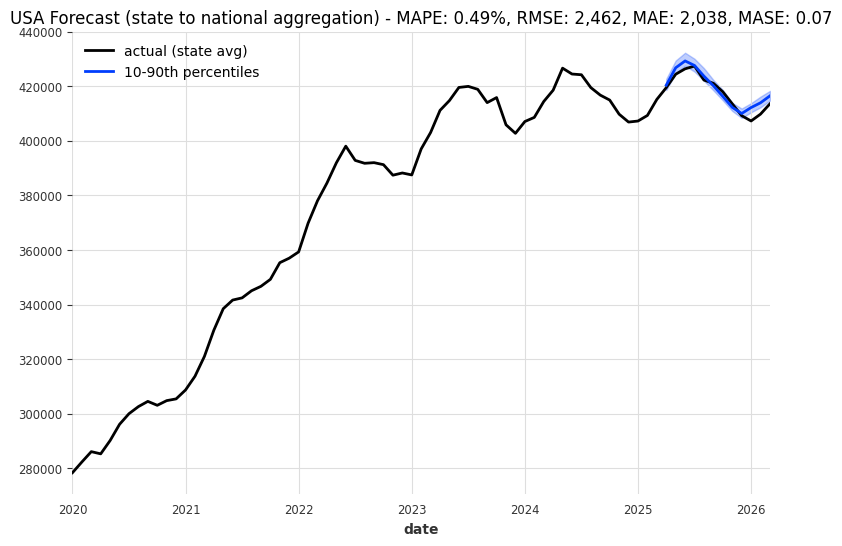

In [118]:
# Evaluate: predict for each state, compute per-state MAPE
state_preds = {}
state_mapes = {}

for i, (state_name, data) in enumerate(state_results.items()):
    
    pred = eval_model.predict(
        n=len(data['val_transformed']),
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
        verbose=False
    )
    state_preds[state_name] = pred
    state_mapes[state_name] = mape(data['val_transformed'], pred)

# Summary stats
mape_values = list(state_mapes.values())
print(f"State-level MAPE across {len(mape_values)} states:")
print(f"  Mean:   {np.mean(mape_values):.2f}%")
print(f"  Median: {np.median(mape_values):.2f}%")
print(f"  Min:    {np.min(mape_values):.2f}%")
print(f"  Max:    {np.max(mape_values):.2f}%")

# --- Aggregate state predictions to national level ---
from functools import reduce

national_actual_dfs = []
national_pred_samples = []  # keep all samples for quantile bands

for state_name, data in state_results.items():
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(state_preds[state_name])
    
    # Full actual series (train + val), not just validation
    full_inv = scaler.inverse_transform(data['series_transformed'])
    full_df = full_inv.to_dataframe()
    full_df.columns = [state_name]
    national_actual_dfs.append(full_df)
    
    # Keep all samples (shape: timesteps x 1 x num_samples) for quantile aggregation
    national_pred_samples.append(pred_inv.all_values())  # numpy array

# Full actual series averaged across states
national_actual_df = pd.concat(national_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
national_actual_ts = TimeSeries.from_dataframe(national_actual_df, freq='MS')

# Average prediction samples across states → preserves quantile information
# Each element is (n_timesteps, 1, num_samples); stack and mean over states
national_pred_arr = np.mean(np.array(national_pred_samples), axis=0)  # (n_timesteps, 1, num_samples)

# Build a probabilistic TimeSeries from the averaged samples
pred_time_index = state_preds[list(state_results.keys())[0]].time_index
national_pred_ts = TimeSeries.from_times_and_values(
    times=pred_time_index,
    values=national_pred_arr,
)

national_actual_sliced = national_actual_ts.slice(national_pred_ts.start_time(), national_pred_ts.end_time())
national_train_ts = national_actual_ts.slice(
    national_actual_ts.start_time(),
    national_pred_ts.start_time() - pd.DateOffset(months=1)
)

national_mape = mape(national_actual_sliced, national_pred_ts)
national_rmse = rmse(national_actual_sliced, national_pred_ts)
national_mae = mae(national_actual_sliced, national_pred_ts)
national_mase = mase(national_actual_sliced, national_pred_ts, insample=national_train_ts, m=12)

print(f"\n  (USA) national aggregated MAPE: {national_mape:.2f}%")
print(f"  (USA) national aggregated RMSE: {national_rmse:,.0f}")
print(f"  (USA) national aggregated MAE:  {national_mae:,.0f}")
print(f"  (USA) national aggregated MASE: {national_mase:.2f}")

# Plot national-level result with full actuals and quantile bands
plt.figure(figsize=figsize)
national_actual_ts.plot(label="actual (state avg)")
national_pred_ts.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
plt.title(f"USA Forecast (state to national aggregation) - MAPE: {national_mape:.2f}%, RMSE: {national_rmse:,.0f}, MAE: {national_mae:,.0f}, MASE: {national_mase:.2f}")
plt.legend()


Forecasts generated for 51 states

State       MAPE%         RMSE          MAE     MASE Forecast Range
----------------------------------------------------------------------
  AK        7.88%      37,519      32,723    0.51   $384,334 → $415,467
  AL        4.86%      14,169      13,924    0.68   $272,778 → $283,273
  AR        4.76%      12,063      11,535    0.61   $233,257 → $226,716
  AZ        0.79%       4,193       3,537    0.12   $452,114 → $447,164
  CA        1.73%      14,452      12,055    0.42   $721,093 → $712,349
  CO        3.54%      22,652      22,327    0.46   $652,502 → $644,198
  CT        2.42%      14,726      13,613    0.32   $551,524 → $531,345
  DC       13.40%      79,695      75,090    1.44   $642,156 → $643,555
  DE        2.19%      13,173      10,280    0.30   $454,023 → $441,365
  FL        2.53%      11,690      10,482    0.32   $424,430 → $410,075
  GA        1.92%       6,906       6,537    0.26   $338,923 → $331,275
  HI        7.43%      72,466     

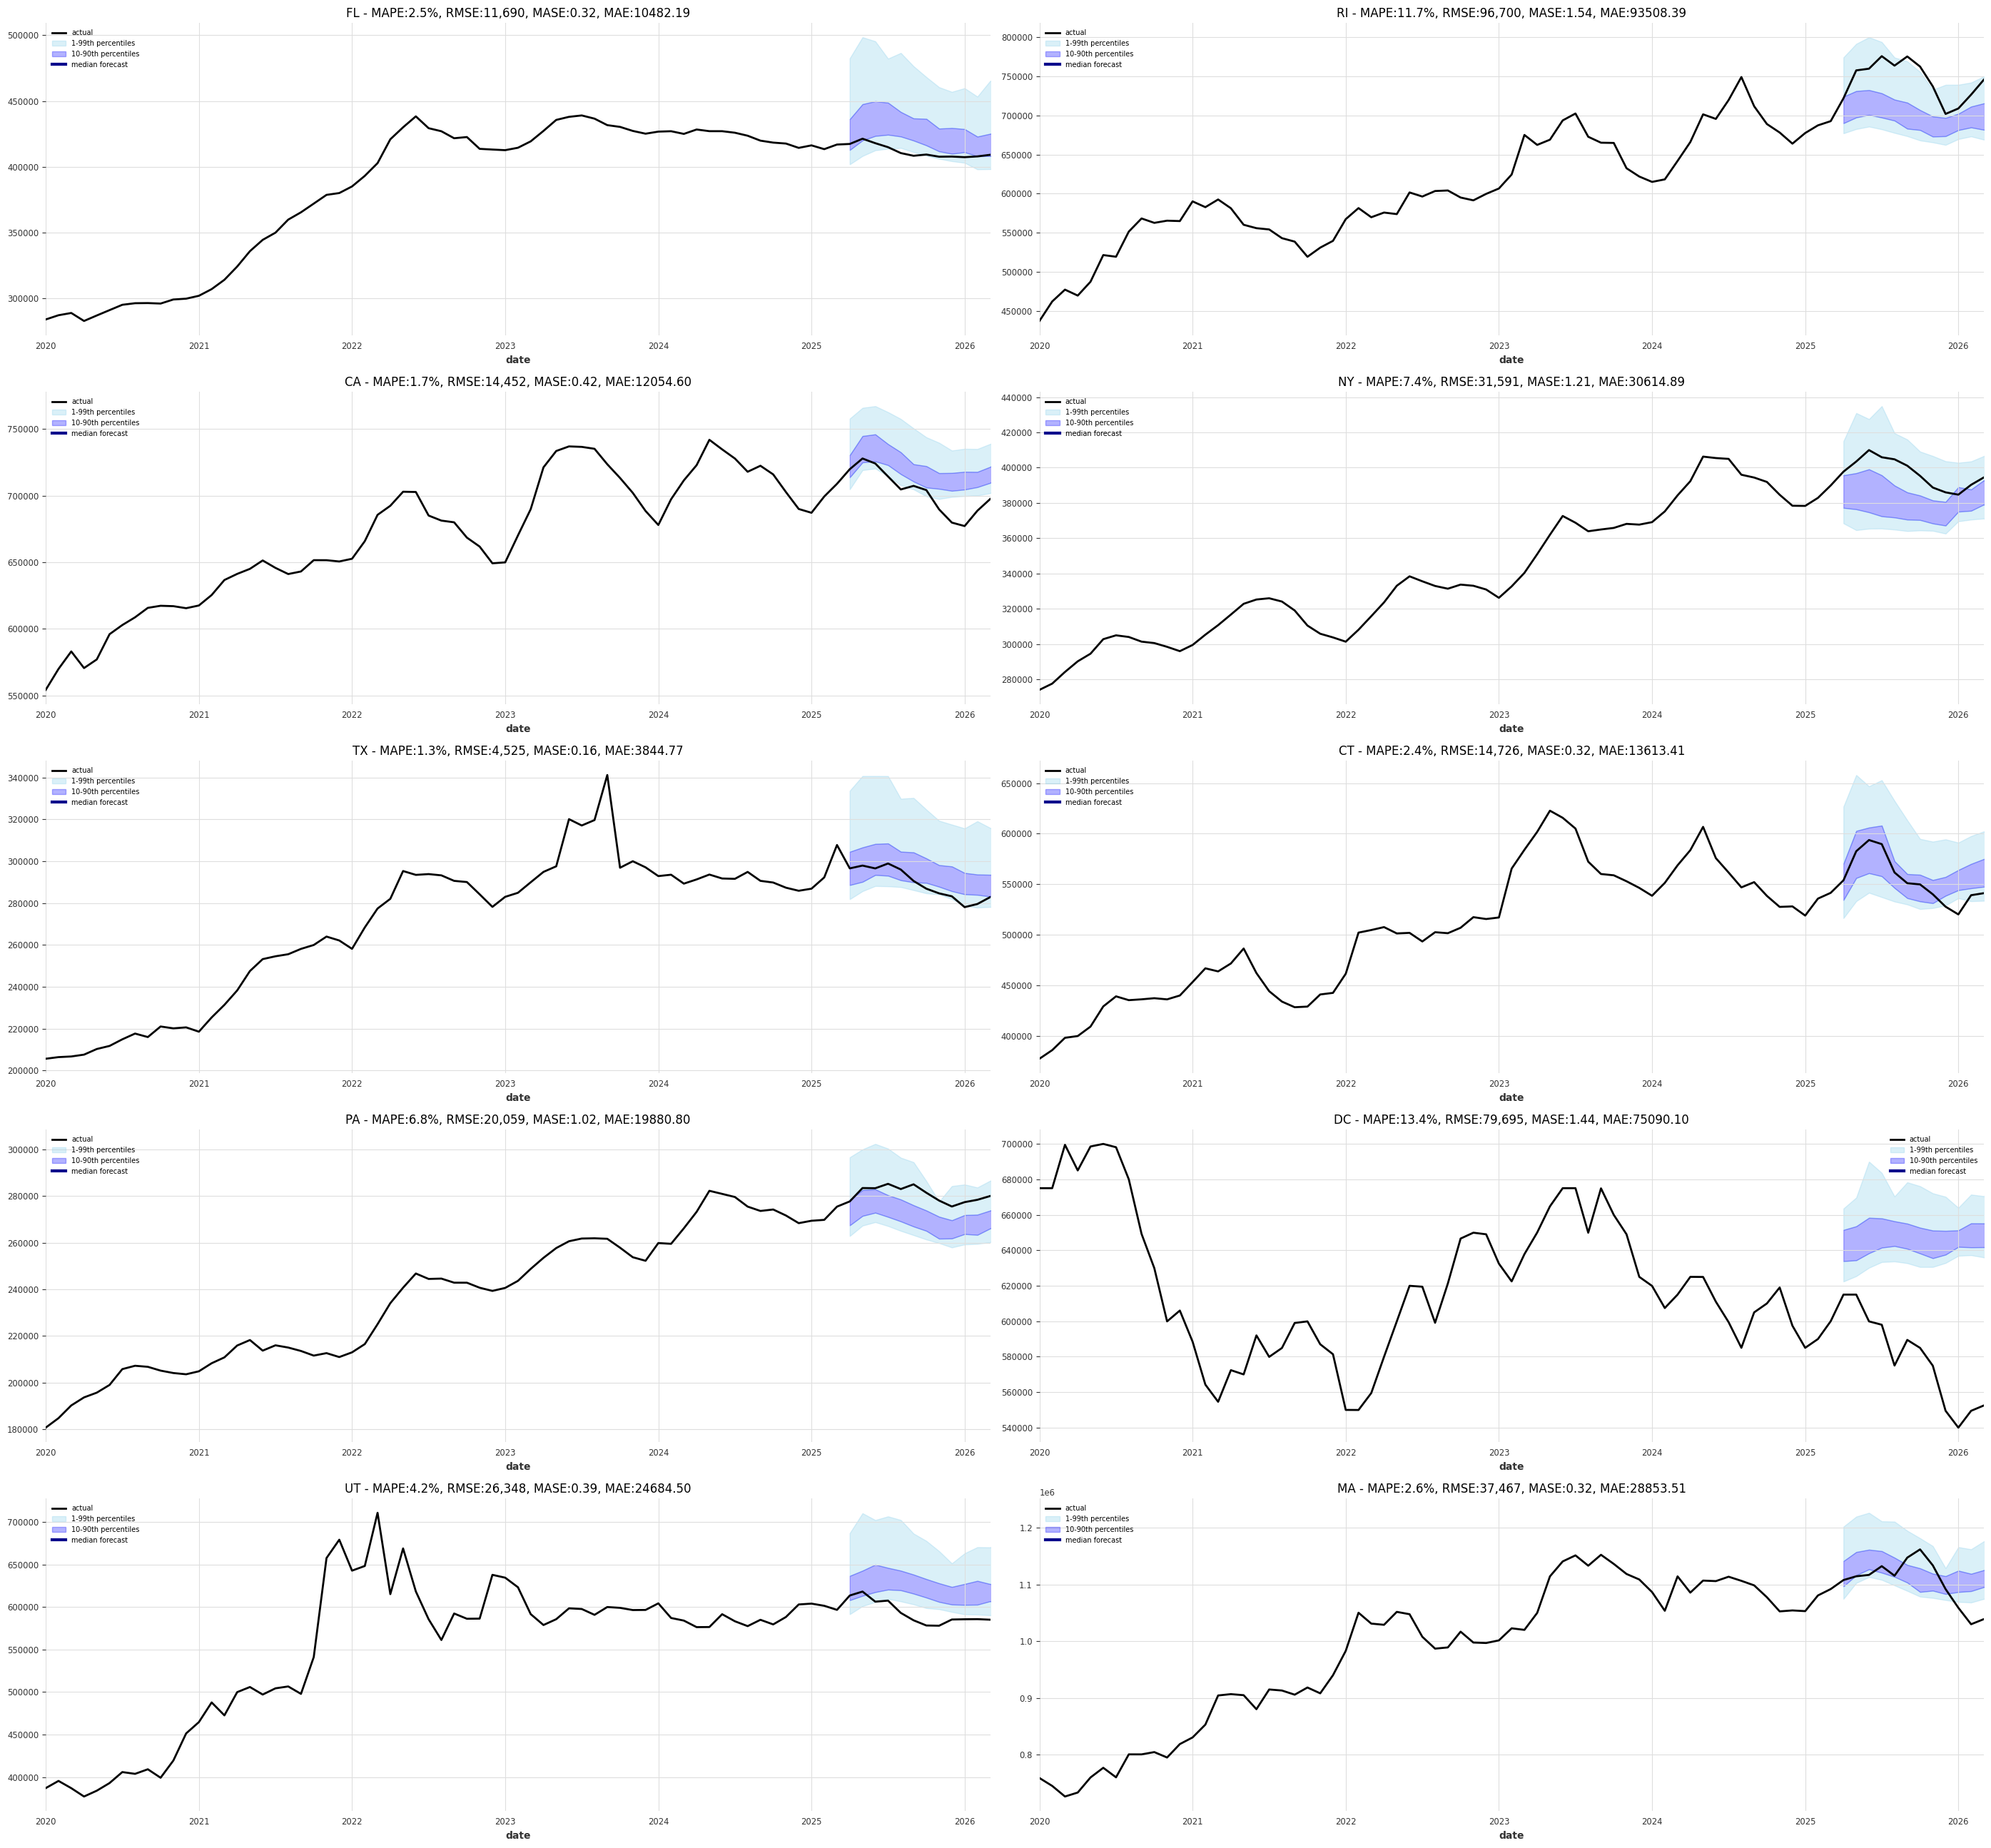

In [119]:
#state-level predictions and metrics

# Settings
num_samples = 200
forecast_horizon = 18
low_q, high_q = 0.1, 0.9
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

# Generate predictions for each state
state_preds = {}
for state_name, data in state_results.items():
    pred = eval_model.predict(
        n=forecast_horizon,
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
        verbose=False,
    )
    state_preds[state_name] = pred

# Inverse-transform predictions back to original scale and compute metrics
state_preds_inv = {}
state_metrics = {}
for state_name, pred in state_preds.items():
    data = state_results[state_name]
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(pred)
    val_inv = scaler.inverse_transform(data['val_transformed'])
    train_inv = scaler.inverse_transform(data['train_transformed'])

    state_preds_inv[state_name] = pred_inv
    state_metrics[state_name] = {
        'MAPE': mape(val_inv, pred_inv),
        'RMSE': rmse(val_inv, pred_inv),
        'MAE': mae(val_inv, pred_inv),
        'MASE': mase(val_inv, pred_inv, insample=train_inv, m=12),
    }

# Print metrics per state
print(f"Forecasts generated for {len(state_preds)} states\n")
print(f"{'State':<8} {'MAPE%':>8} {'RMSE':>12} {'MAE':>12} {'MASE':>8} {'Forecast Range'}")
print("-" * 70)
for state_name in sorted(state_metrics.keys()):
    m = state_metrics[state_name]
    pred_inv = state_preds_inv[state_name]
    median_vals = np.median(pred_inv.all_values()[:, 0, :], axis=1)
    print(f"  {state_name.upper():<6} {m['MAPE']:>7.2f}% {m['RMSE']:>11,.0f} {m['MAE']:>11,.0f} {m['MASE']:>7.2f}   ${median_vals[0]:,.0f} → ${median_vals[-1]:,.0f}")

# Summary stats across all states
print(f"\n{'Metric':<8} {'Mean':>10} {'Median':>10} {'Min':>10} {'Max':>10}")
print("-" * 50)
for metric_name in ['MAPE', 'RMSE', 'MAE', 'MASE']:
    vals = [m[metric_name] for m in state_metrics.values()]
    fmt = '.2f' if metric_name in ['MAPE', 'MASE'] else ',.0f'
    print(f"  {metric_name:<6} {np.mean(vals):>10{fmt}} {np.median(vals):>10{fmt}} {np.min(vals):>10{fmt}} {np.max(vals):>10{fmt}}")

# Plot a few states
lowest_q, highest_q = 0.01, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"

sample_states = ['fl', 'ri', 'ca', 'ny', 'tx', 'ct', 'pa', 'dc', 'ut', 'ma']  # edit this list to select states
sample_states = [s for s in sample_states if s in state_results]

fig, axes = plt.subplots(5, 2, figsize=(28, 26))
axes = axes.flatten()

for ax, state_name in zip(axes, sample_states):
    data = state_results[state_name]
    scaler = data['scaler_target']
    actual_inv = scaler.inverse_transform(data['series_transformed'])
    pred_inv = state_preds_inv[state_name]
    m = state_metrics[state_name]
    
    # Extract time index and sample values for manual quantile bands
    times = pred_inv.time_index
    samples = pred_inv.all_values()[:, 0, :]  # (timesteps, num_samples)
    q_01 = np.quantile(samples, lowest_q, axis=1)
    q_10 = np.quantile(samples, low_q, axis=1)
    q_90 = np.quantile(samples, high_q, axis=1)
    q_99 = np.quantile(samples, highest_q, axis=1)
    q_50 = np.median(samples, axis=1)

    plt.sca(ax)
    actual_inv.plot(label="actual")
    # Outer band (1-10th and 90-99th percentiles) in sky blue
    ax.fill_between(times, q_01, q_10, alpha=0.3, color='skyblue', label=label_q_outer)
    ax.fill_between(times, q_90, q_99, alpha=0.3, color='skyblue')
    # Inner band (10-90th percentiles)
    ax.fill_between(times, q_10, q_90, alpha=0.3, color='blue', label=label_q_inner)
    # Median line
    ax.plot(times, q_50, color='darkblue', linewidth=3, label="median forecast")
    
    ax.set_title(f"{state_name.upper()} - MAPE:{m['MAPE']:.1f}%, RMSE:{m['RMSE']:,.0f}, MASE:{m['MASE']:.2f}, MAE:{m['MAE']:.2f}")
    ax.legend(fontsize=7)

for ax in axes[len(sample_states):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Future

### Future - USA

Future forecasts generated for 51 states

National 18-Month Future Forecast (state average)
  Period: 2026-04 → 2027-03
  Median: $418,328 → $426,580
  90% range: $416,246–$420,419 → $424,592–$428,896


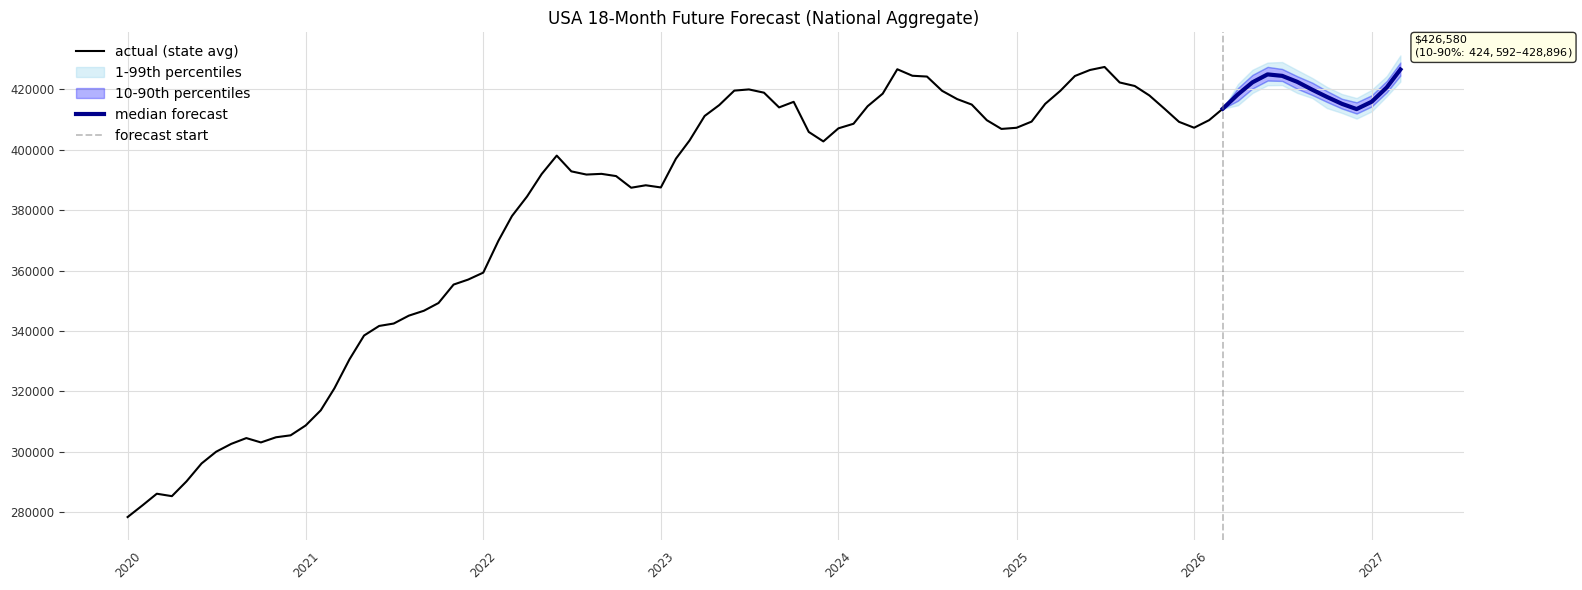

In [ ]:
# 18-month future forecast — national aggregate
# Uses the FULL series (train + val) to predict the next 18 months beyond available data

future_preds = {}
skipped_future = []
output_chunk_length = forecast_horizon + 6  # must match model's output_chunk_length (18)

for state_name, data in state_results.items():
    scaler = data['scaler_target']
    full_series = data['series_transformed']
    past_cov = data['past_cov_transformed']

    # Extend future covariates on UNSCALED data, then re-scale the whole thing
    # This avoids injecting raw values (e.g. year=2026) into an already-scaled DataFrame
    fut_cov_unscaled = data['fut_cov_unscaled']
    scaler_future = data['scaler_future']

    if fut_cov_unscaled.end_time() < full_series.end_time() + pd.DateOffset(months=output_chunk_length - 1):
        fut_df = fut_cov_unscaled.to_dataframe()
        extra_months = output_chunk_length
        future_dates = pd.date_range(
            start=fut_df.index[-1] + pd.DateOffset(months=1),
            periods=extra_months,
            freq='MS',
        )
        extension = pd.DataFrame([fut_df.iloc[-1]] * extra_months, index=future_dates)
        # Update time-varying columns with proper values for each future date
        if 'year' in extension.columns:
            extension['year'] = [d.year for d in future_dates]
        if 'linear_increase' in extension.columns:
            last_val = fut_df['linear_increase'].iloc[-1]
            extension['linear_increase'] = np.arange(last_val + 1, last_val + 1 + extra_months)
        # Recalculate month sin/cos for future dates
        if 'month_sin' in extension.columns:
            extension['month_sin'] = np.sin(2 * np.pi * np.array([d.month for d in future_dates]) / 12)
        if 'month_cos' in extension.columns:
            extension['month_cos'] = np.cos(2 * np.pi * np.array([d.month for d in future_dates]) / 12)
        fut_extended_df = pd.concat([fut_df, extension]).astype(np.float32)
        fut_cov_extended = TimeSeries.from_dataframe(fut_extended_df, freq='MS')
        # Scale the entire extended series using the stored scaler
        fut_cov = scaler_future.transform(fut_cov_extended)
    else:
        fut_cov = data['future_cov_transformed']

    try:
        pred = eval_model.predict(
            n=forecast_horizon,
            series=full_series,
            future_covariates=fut_cov,
            past_covariates=past_cov,
            num_samples=num_samples,
            verbose=False,
        )
        future_preds[state_name] = pred
    except Exception as e:
        skipped_future.append((state_name, str(e)))

print(f"Future forecasts generated for {len(future_preds)} states")

if skipped_future:
    print(f"Skipped {len(skipped_future)} states:")
    for name, reason in skipped_future:
        print(f"  {name}: {reason}")

# Inverse-transform and aggregate to national level
national_future_samples = []
national_actual_dfs = []

for state_name, pred in future_preds.items():
    scaler = state_results[state_name]['scaler_target']
    pred_inv = scaler.inverse_transform(pred)
    national_future_samples.append(pred_inv.all_values())  # (timesteps, 1, num_samples)

    # Full actual history for plotting
    full_inv = scaler.inverse_transform(state_results[state_name]['series_transformed'])
    full_df = full_inv.to_dataframe()
    full_df.columns = [state_name]
    national_actual_dfs.append(full_df)

# National average: actual history
national_actual_df = pd.concat(national_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
national_actual_ts = TimeSeries.from_dataframe(national_actual_df, freq='MS')

# National average: future prediction samples
national_future_arr = np.mean(np.array(national_future_samples), axis=0)  # (timesteps, 1, num_samples)
future_time_index = future_preds[list(future_preds.keys())[0]].time_index
national_future_ts = TimeSeries.from_times_and_values(
    times=future_time_index,
    values=national_future_arr,
)

# Extract quantile bands
samples = national_future_arr[:, 0, :]  # (timesteps, num_samples)
q_01 = np.quantile(samples, lowest_q, axis=1)
q_10 = np.quantile(samples, low_q, axis=1)
q_90 = np.quantile(samples, high_q, axis=1)
q_99 = np.quantile(samples, highest_q, axis=1)
q_50 = np.median(samples, axis=1)

# Print forecast summary
print(f"\nNational 18-Month Future Forecast (state average)")
print(f"  Period: {future_time_index[0].strftime('%Y-%m')} → {future_time_index[-1].strftime('%Y-%m')}")
print(f"  Median: ${q_50[0]:,.0f} → ${q_50[-1]:,.0f}")
print(f"  90% range: ${q_10[0]:,.0f}–${q_90[0]:,.0f} → ${q_10[-1]:,.0f}–${q_90[-1]:,.0f}")

# Plot — full history + 18-month forecast
fig, ax = plt.subplots(figsize=(16, 6))
actual_times = national_actual_ts.time_index
actual_vals = national_actual_ts.values().flatten()
ax.plot(actual_times, actual_vals, color='black', linewidth=1.5, label="actual (state avg)")
# Prepend last actual point so forecast bands start seamlessly from actuals
last_actual_val = actual_vals[-1]
fti_ext = pd.DatetimeIndex([actual_times[-1]]).append(future_time_index)
q_01_ext = np.concatenate([[last_actual_val], q_01])
q_10_ext = np.concatenate([[last_actual_val], q_10])
q_90_ext = np.concatenate([[last_actual_val], q_90])
q_99_ext = np.concatenate([[last_actual_val], q_99])
q_50_ext = np.concatenate([[last_actual_val], q_50])
ax.fill_between(fti_ext, q_01_ext, q_10_ext, alpha=0.3, color='skyblue', label=label_q_outer)
ax.fill_between(fti_ext, q_90_ext, q_99_ext, alpha=0.3, color='skyblue')
ax.fill_between(fti_ext, q_10_ext, q_90_ext, alpha=0.3, color='blue', label=label_q_inner)
ax.plot(fti_ext, q_50_ext, color='darkblue', linewidth=3, label="median forecast")
ax.axvline(x=national_actual_ts.end_time(), color='gray', linestyle='--', alpha=0.5, label='forecast start')

# Annotate final forecast range
ax.annotate(f'${q_50[-1]:,.0f}\n({int(low_q*100)}-{int(high_q*100)}%: ${q_10[-1]:,.0f}–${q_90[-1]:,.0f})',
            xy=(future_time_index[-1], q_50[-1]), fontsize=8,
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))

plt.xticks(rotation=45)
ax.set_title("USA 18-Month Future Forecast (National Aggregate)")
ax.legend()
plt.tight_layout()
plt.show()

## Future — By State

State           Start          End   Median Start     Median End 90% Range End
--------------------------------------------------------------------------------
  AK          2026-04      2027-09   $   387,087   $   413,138   $398,433–$424,759
  AL          2026-04      2027-09   $   275,061   $   284,925   $280,938–$289,949
  AR          2026-04      2027-09   $   233,608   $   230,429   $225,745–$232,717
  AZ          2026-04      2027-09   $   451,525   $   442,811   $434,483–$451,102
  CA          2026-04      2027-09   $   699,008   $   688,233   $680,870–$694,810
  CO          2026-04      2027-09   $   638,552   $   624,123   $612,932–$633,382
  CT          2026-04      2027-09   $   548,096   $   522,805   $512,220–$529,942
  DC          2026-04      2027-09   $   626,923   $   634,823   $627,808–$641,681
  DE          2026-04      2027-09   $   459,775   $   444,357   $436,799–$452,228
  FL          2026-04      2027-09   $   420,809   $   426,254   $414,918–$436,765
  GA      

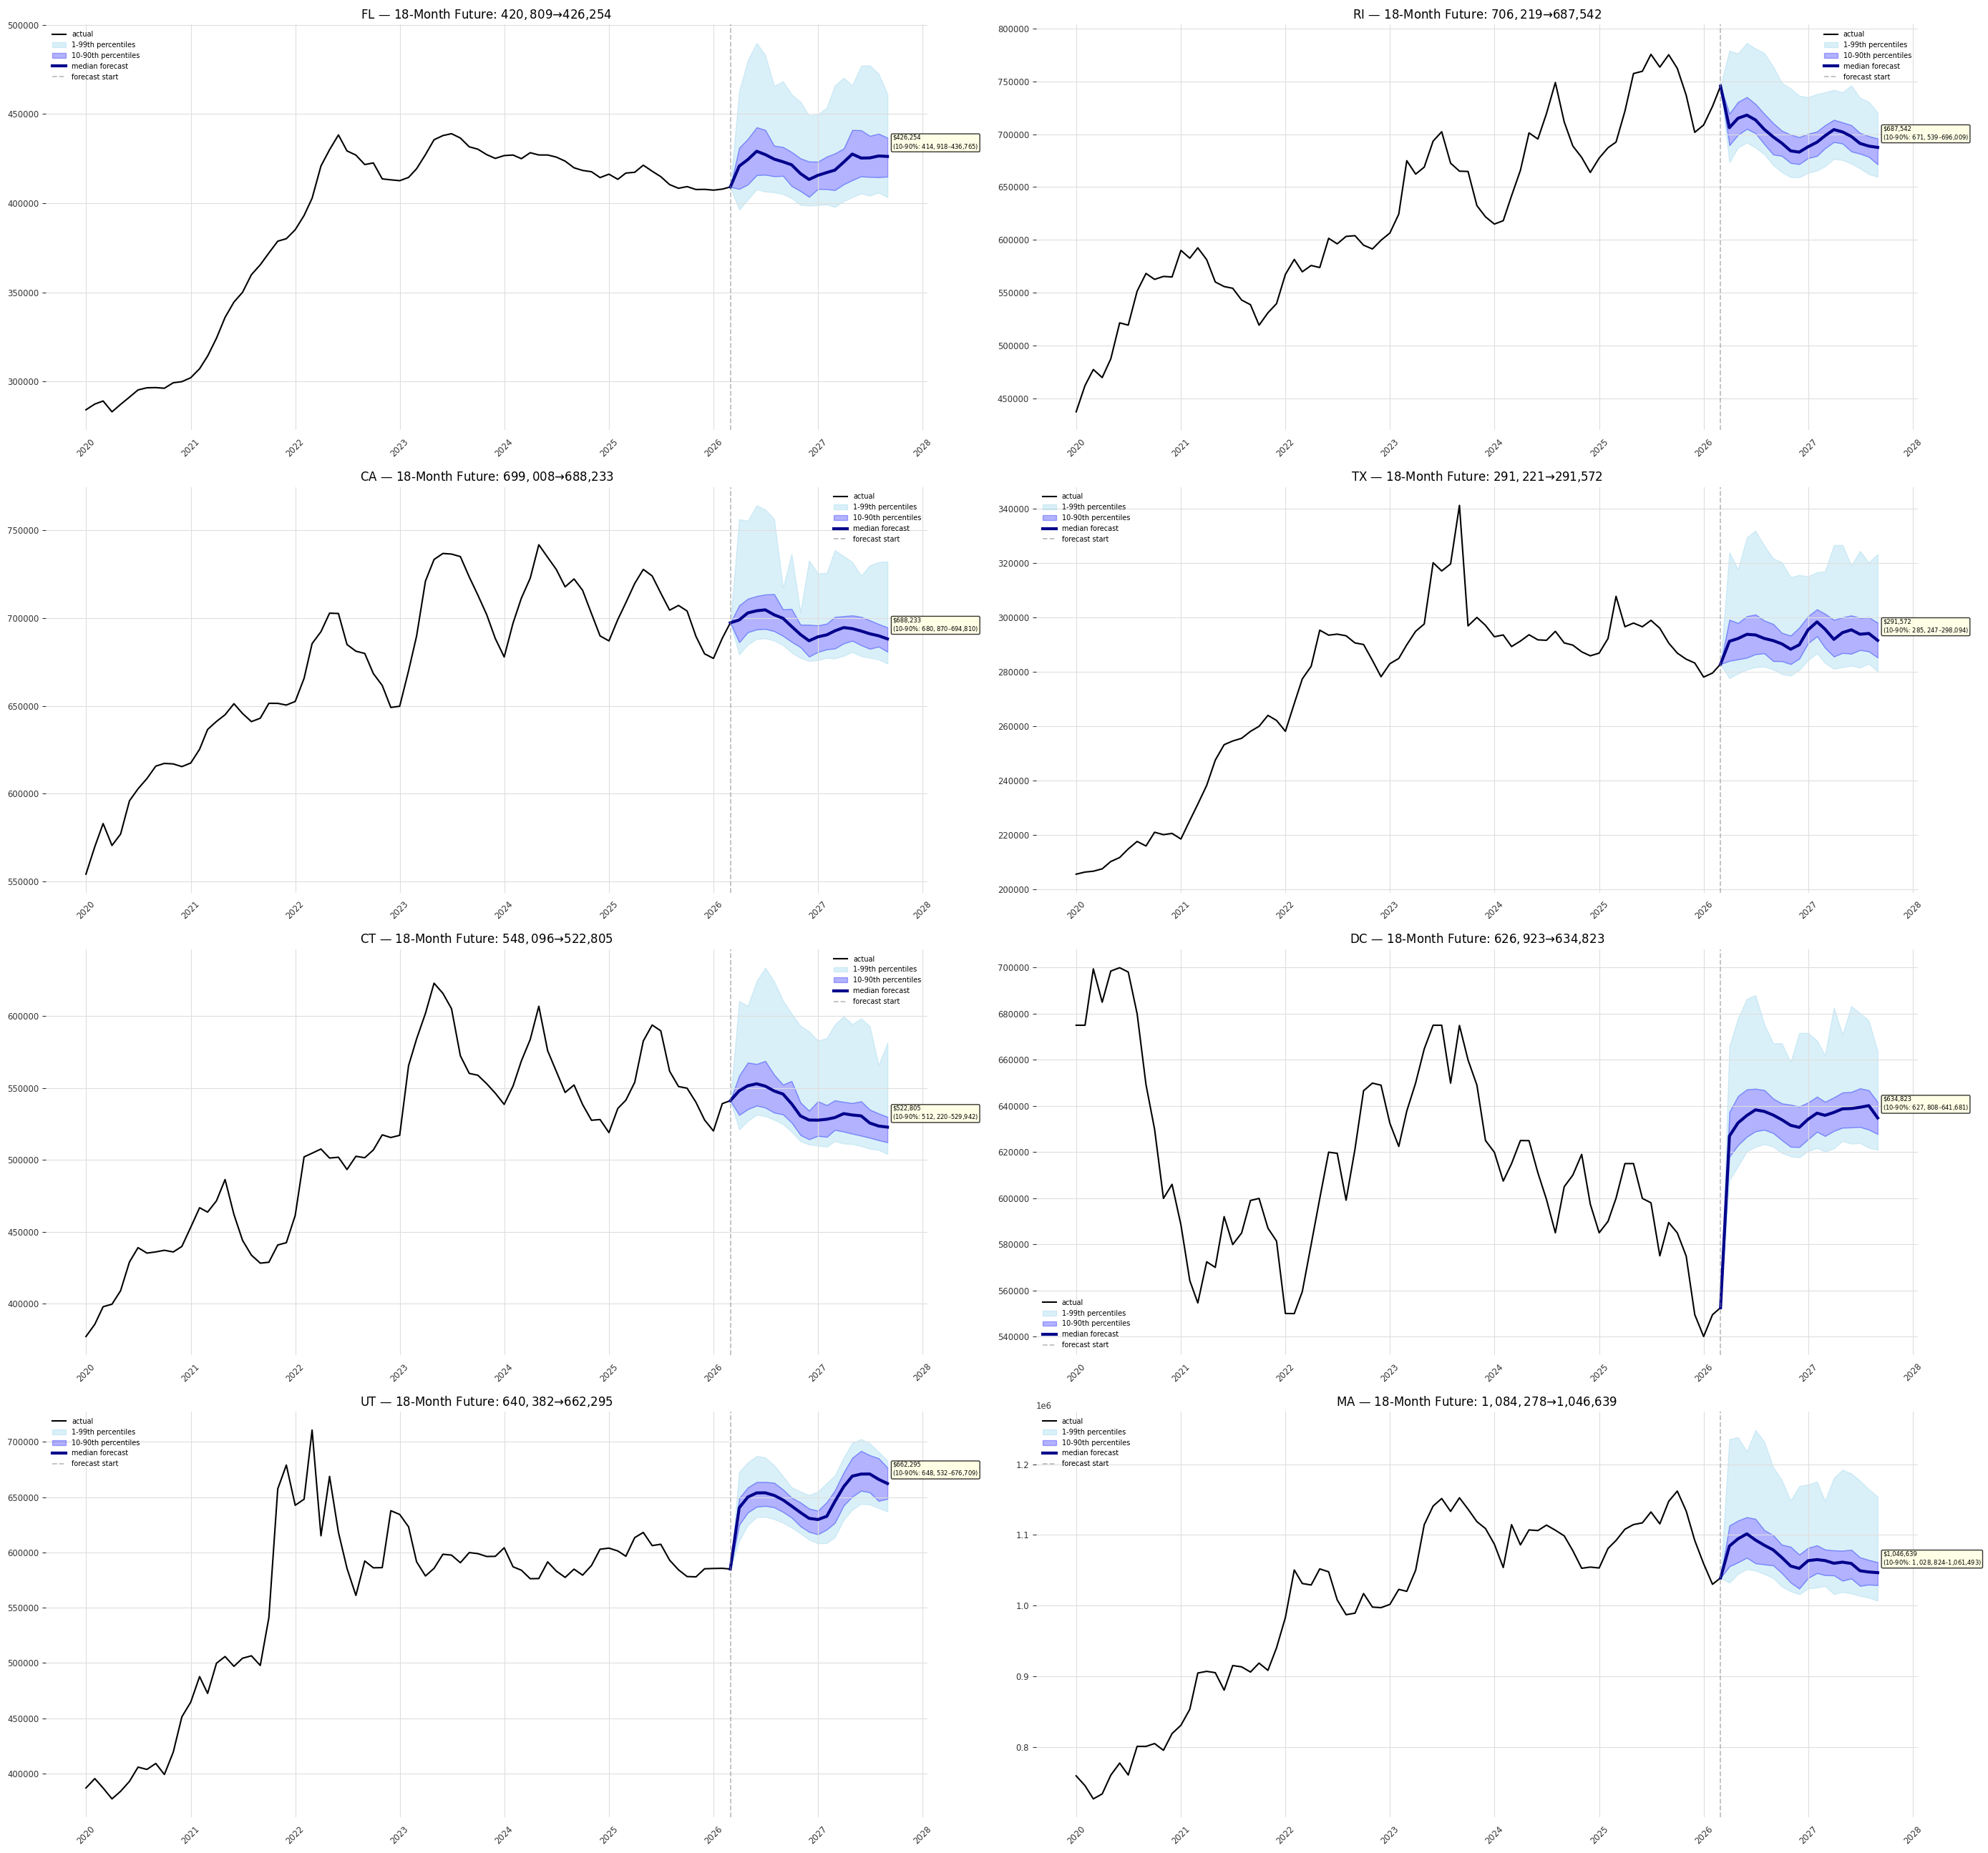

In [121]:
# 18-month future forecast — by state

sample_states_future = ['fl', 'ri', 'ca', 'tx', 'ct', 'dc', 'ut', 'ma']
sample_states_future = [s for s in sample_states_future if s in future_preds]

# Inverse-transform all predictions
future_preds_inv = {}
for state_name, pred in future_preds.items():
    scaler = state_results[state_name]['scaler_target']
    future_preds_inv[state_name] = scaler.inverse_transform(pred)

# Print per-state forecast table
print(f"{'State':<8} {'Start':>12} {'End':>12} {'Median Start':>14} {'Median End':>14} {'90% Range End'}")
print("-" * 80)
for state_name in sorted(future_preds_inv.keys()):
    pred_inv = future_preds_inv[state_name]
    samples = pred_inv.all_values()[:, 0, :]
    q_50 = np.median(samples, axis=1)
    q_10 = np.quantile(samples, low_q, axis=1)
    q_90 = np.quantile(samples, high_q, axis=1)
    t0 = pred_inv.time_index[0].strftime('%Y-%m')
    t1 = pred_inv.time_index[-1].strftime('%Y-%m')
    print(f"  {state_name.upper():<6} {t0:>12} {t1:>12}   ${q_50[0]:>10,.0f}   ${q_50[-1]:>10,.0f}   ${q_10[-1]:,.0f}–${q_90[-1]:,.0f}")

# Plot by state
fig, axes = plt.subplots(4, 2, figsize=(28, 26))
axes = axes.flatten()

for ax, state_name in zip(axes, sample_states_future):
    data = state_results[state_name]
    scaler = data['scaler_target']
    actual_inv = scaler.inverse_transform(data['series_transformed'])
    pred_inv = future_preds_inv[state_name]

    # Quantile bands
    times = pred_inv.time_index
    samples = pred_inv.all_values()[:, 0, :]
    q_01 = np.quantile(samples, lowest_q, axis=1)
    q_10 = np.quantile(samples, low_q, axis=1)
    q_90 = np.quantile(samples, high_q, axis=1)
    q_99 = np.quantile(samples, highest_q, axis=1)
    q_50 = np.median(samples, axis=1)

    plt.sca(ax)
    # Plot actual history using matplotlib directly (darts .plot() overrides axis formatting)
    act_times = actual_inv.time_index
    act_vals = actual_inv.values().flatten()
    ax.plot(act_times, act_vals, color='black', linewidth=1.5, label="actual")
    # Prepend last actual point so forecast bands start seamlessly from actuals
    last_actual_val = act_vals[-1]
    times_ext = pd.DatetimeIndex([act_times[-1]]).append(times)
    q_01_ext = np.concatenate([[last_actual_val], q_01])
    q_10_ext = np.concatenate([[last_actual_val], q_10])
    q_90_ext = np.concatenate([[last_actual_val], q_90])
    q_99_ext = np.concatenate([[last_actual_val], q_99])
    q_50_ext = np.concatenate([[last_actual_val], q_50])
    ax.fill_between(times_ext, q_01_ext, q_10_ext, alpha=0.3, color='skyblue', label=label_q_outer)
    ax.fill_between(times_ext, q_90_ext, q_99_ext, alpha=0.3, color='skyblue')
    ax.fill_between(times_ext, q_10_ext, q_90_ext, alpha=0.3, color='blue', label=label_q_inner)
    ax.plot(times_ext, q_50_ext, color='darkblue', linewidth=3, label="median forecast")
    ax.axvline(x=actual_inv.end_time(), color='gray', linestyle='--', alpha=0.5, label='forecast start')

    # Annotate final forecast range
    ax.annotate(f'${q_50[-1]:,.0f}\n({int(low_q*100)}-{int(high_q*100)}%: ${q_10[-1]:,.0f}–${q_90[-1]:,.0f})',
                xy=(times[-1], q_50[-1]), fontsize=6,
                xytext=(5, 8), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"{state_name.upper()} — 18-Month Future: ${q_50[0]:,.0f} → ${q_50[-1]:,.0f}")
    ax.legend(fontsize=7)


for ax in axes[len(sample_states_future):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()